# Training ResNet50 on TrashNet

Notebook da duoc lam gon lai theo section ro rang, giu nguyen logic huan luyen mo hinh.


## 1. Imports


In [1]:
import os
import random
import multiprocessing
import shutil
import urllib.request
import zipfile
from contextlib import nullcontext
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch.utils.data import random_split
from torch.utils.data.dataloader import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid


## 2. Training Utilities


In [2]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))


class ImageClassification(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validating(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'Validation Loss': loss.detach(), 'Validation Accuracy': acc}

    def validating_epoch_final(self, outputs):
        batch_loss = [x['Validation Loss'] for x in outputs]
        epoch_loss = torch.stack(batch_loss).mean()
        batch_accuracy = [x['Validation Accuracy'] for x in outputs]
        epoch_accuracy = torch.stack(batch_accuracy).mean()
        return {'Validation Loss': epoch_loss.item(), 'Validation Accuracy': epoch_accuracy.item()}

    def epoch_final(self, epoch, result):
        print(
            'Epoch [{}], Training Loss: {:.4f}, Validation Loss: {:.4f}, Validation Accuracy: {:.4f}'.format(
                epoch + 1,
                result['Training Loss'],
                result['Validation Loss'],
                result['Validation Accuracy'],
            )
        )


class EarlyStopping:
    def __init__(self, patience=5, verbose=False, restore_best_weights=True):
        self.patience = patience
        self.verbose = verbose
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False
        self.restore_best_weights = restore_best_weights
        self.best_model_weights = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_model_weights = model.state_dict().copy()
            if self.verbose:
                print(f'Validation loss improved: {val_loss:.4f}')
        else:
            self.counter += 1
            if self.verbose:
                print(f'Validation loss did not improve: {val_loss:.4f}')
            if self.counter >= self.patience:
                self.early_stop = True
                if self.restore_best_weights and self.best_model_weights is not None:
                    model.load_state_dict(self.best_model_weights)
                    if self.verbose:
                        print('Restored best model weights.')


## 3. Evaluation and Visualization Helpers


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def denormalize_image(image_tensor):
    image = image_tensor.detach().cpu().clone()
    for channel, mean, std in zip(image, IMAGENET_MEAN, IMAGENET_STD):
        channel.mul_(std).add_(mean)
    return image.clamp(0, 1)


def export_classification_metrics(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images, labels = batch
            images = move_to_gpu(images, device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    for i, class_name in enumerate(classes):
        class_labels = [1 if label == i else 0 for label in all_labels]
        class_preds = [1 if pred == i else 0 for pred in all_preds]

        accuracy = accuracy_score(class_labels, class_preds) * 100
        precision = precision_score(class_labels, class_preds, zero_division=0) * 100
        recall = recall_score(class_labels, class_preds, zero_division=0) * 100
        f1 = f1_score(class_labels, class_preds, zero_division=0) * 100

        print(
            f'{class_name}, accuracy: {accuracy:.2f}%, precision: {precision:.2f}%, '
            f'recall: {recall:.2f}%, F1 score: {f1:.2f}%'
        )


def plot_accuracy_per_class(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images, labels = batch
            images = move_to_gpu(images, device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracies = []
    for i, class_name in enumerate(classes):
        class_labels = [1 if label == i else 0 for label in all_labels]
        class_preds = [1 if pred == i else 0 for pred in all_preds]

        accuracy = accuracy_score(class_labels, class_preds) * 100
        accuracies.append(accuracy)

    plt.bar(classes, accuracies)
    plt.xlabel('Classes')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy per Class')
    plt.xticks(rotation=45)
    plt.show()


def plot_confusion_matrix(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images, labels = batch
            images = move_to_gpu(images, device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=classes)

    plt.figure(figsize=(10, 10))
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
    plt.title('Confusion Matrix')
    plt.show()


def display_test(image, label):
    print('Label:', dataset.classes[label], '(Class No: ' + str(label) + ')')
    plt.imshow(denormalize_image(image).permute(1, 2, 0))
    plt.show()


def batch_visualization(data):
    for image, labels in data:
        fig, ax = plt.subplots(figsize=(14, 14))
        ax.set_xticks([])
        ax.set_yticks([])
        preview = torch.stack([denormalize_image(img) for img in image[:32]])
        ax.imshow(make_grid(preview, nrow=16).permute(1, 2, 0))
        plt.show()
        break


def predict(image, model):
    xb = move_to_gpu(image.unsqueeze(0), device)
    yb = model(xb)
    _, preds = torch.max(yb, dim=1)
    return dataset.classes[preds[0].item()]


## 4. Dataset Loading and Augmentation


['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Dataset directory: /content/trashnet_data/dataset-resized
Environment: Colab/Local
Label: trash (Class No: 5)


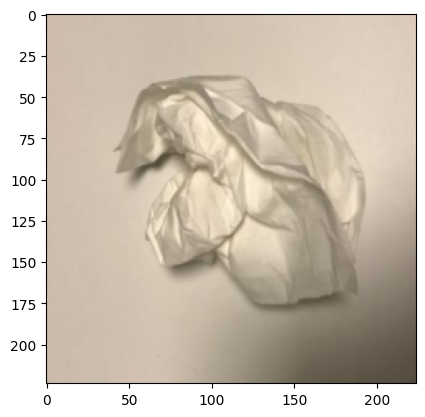

In [16]:
KAGGLE_DATASET_DIR = Path('/kaggle/input/trashnet/dataset-resized')
KAGGLE_WORKING_DIR = Path('/kaggle/working')
COLAB_ROOT = Path('/content')
DATA_ROOT = COLAB_ROOT / 'trashnet_data'
DOWNLOAD_DIR = DATA_ROOT / 'downloads'
RAW_DIR = DATA_ROOT / 'raw'
COLAB_DATASET_DIR = DATA_ROOT / 'dataset-resized'


def running_on_kaggle():
    return KAGGLE_DATASET_DIR.exists()


def running_on_colab():
    return COLAB_ROOT.exists()


def prepare_trashnet_dataset():
    if running_on_kaggle():
        return KAGGLE_DATASET_DIR

    if COLAB_DATASET_DIR.exists():
        return COLAB_DATASET_DIR

    DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
    RAW_DIR.mkdir(parents=True, exist_ok=True)

    archive_path = DOWNLOAD_DIR / 'trashnet-master.zip'
    if not archive_path.exists():
        urllib.request.urlretrieve(
            'https://github.com/garythung/trashnet/archive/refs/heads/master.zip',
            archive_path,
        )

    extract_dir = RAW_DIR / 'trashnet-master'
    if not extract_dir.exists():
        with zipfile.ZipFile(archive_path, 'r') as zip_ref:
            zip_ref.extractall(RAW_DIR)

    nested_archive = extract_dir / 'data' / 'dataset-resized.zip'
    nested_extract_dir = extract_dir / 'data' / 'dataset-resized'
    if not nested_extract_dir.exists():
        with zipfile.ZipFile(nested_archive, 'r') as zip_ref:
            zip_ref.extractall(extract_dir / 'data')

    if COLAB_DATASET_DIR.exists():
        shutil.rmtree(COLAB_DATASET_DIR)
    shutil.copytree(nested_extract_dir, COLAB_DATASET_DIR)
    return COLAB_DATASET_DIR


def resolve_output_path(filename):
    # Ưu tiên kiểm tra Kaggle trước
    if os.path.exists('/kaggle/working'):
        return Path('/kaggle/working') / filename
    # Sau đó mới đến Colab
    if os.path.exists('/content'):
        return Path('/content') / filename
    return Path.cwd() / filename


directory = str(prepare_trashnet_dataset())
global garbage_classes
# Chỉ lấy các thư mục và bỏ qua file ẩn như .DS_Store
garbage_classes = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d)) and not d.startswith('.')])

print(garbage_classes) 
# Kết quả nên là: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
print('Dataset directory:', directory)
print('Environment:', 'Kaggle' if running_on_kaggle() else 'Colab/Local')

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

base_dataset = ImageFolder(directory)
dataset = ImageFolder(directory, transform=eval_transform)

image, label = random.choice(dataset)
display_test(image, label)


## 5. Data Split and Device Setup


Processing via: cuda
GPU count: 2
num_workers: 4
AMP enabled: True


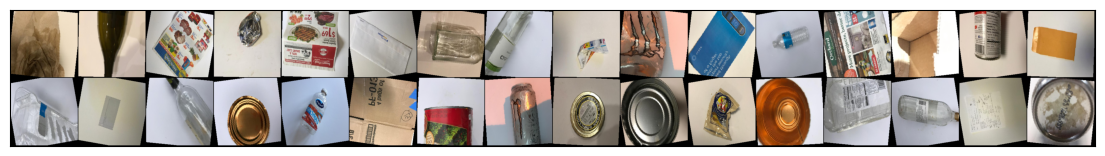

In [5]:
random_seed = 43
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)
    torch.backends.cudnn.benchmark = True

train_size = int(0.6 * len(base_dataset))
val_size = int(0.2 * len(base_dataset))
test_size = len(base_dataset) - train_size - val_size
train_indices, val_indices, test_indices = random_split(
    range(len(base_dataset)),
    [train_size, val_size, test_size],
)

train_dataset = ImageFolder(directory, transform=train_transform)
eval_dataset = ImageFolder(directory, transform=eval_transform)

train_data = torch.utils.data.Subset(train_dataset, train_indices.indices)
val_data = torch.utils.data.Subset(eval_dataset, val_indices.indices)
test_data = torch.utils.data.Subset(eval_dataset, test_indices.indices)

dataset = eval_dataset
batch_size = 64
num_workers = min(4, multiprocessing.cpu_count())
pin_memory = torch.cuda.is_available()
loader_kwargs = {
    'num_workers': num_workers,
    'pin_memory': pin_memory,
}
if num_workers > 0:
    loader_kwargs['persistent_workers'] = True
    loader_kwargs['prefetch_factor'] = 2

train = DataLoader(train_data, batch_size, shuffle=True, **loader_kwargs)
validation = DataLoader(val_data, batch_size * 2, shuffle=False, **loader_kwargs)


def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')


def move_to_gpu(data, device):
    if isinstance(data, (list, tuple)):
        return [move_to_gpu(x, device) for x in data]
    return data.to(device, non_blocking=True)


class DataLoad:
    def __init__(self, data, device):
        self.data = data
        self.device = device

    def __iter__(self):
        for batch in self.data:
            yield move_to_gpu(batch, self.device)

    def __len__(self):
        return len(self.data)


device = get_default_device()
amp_enabled = torch.cuda.is_available()
gpu_count = torch.cuda.device_count() if torch.cuda.is_available() else 0
print('Processing via:', device)
print('GPU count:', gpu_count)
print('num_workers:', num_workers)
print('AMP enabled:', amp_enabled)

batch_visualization(train)

train = DataLoad(train, device)
validation = DataLoad(validation, device)


## 6. Model Definition


In [6]:
class ResNet(ImageClassification):
    def __init__(self):
        super().__init__()
        self.network = models.resnet50(weights='ResNet50_Weights.DEFAULT')
        features = self.network.fc.in_features
        self.network.fc = nn.Linear(features, len(garbage_classes))

        if torch.cuda.is_available() and torch.cuda.device_count() > 1:
            self.network = nn.DataParallel(self.network)

    def forward(self, image):
        return torch.sigmoid(self.network(image))

    def training_step(self, batch):
        images, labels = batch
        autocast_context = torch.autocast(device_type='cuda', dtype=torch.float16) if amp_enabled else nullcontext()
        with autocast_context:
            out = self(images)
            loss = F.cross_entropy(out, labels)
        return loss

    def epoch_final(self, epoch, result):
        print(
            'Epoch [{}], Training Loss: {:.4f}, Validation Loss: {:.4f}, Validation Accuracy: {:.4f}'.format(
                epoch + 1,
                result['Train Loss'],
                result['Validation Loss'],
                result['Validation Accuracy'],
            )
        )


model = move_to_gpu(ResNet(), device)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 158MB/s] 


## 7. Training Loop


In [7]:
@torch.no_grad()
def evaluate(model, validator):
    model.eval()
    outputs = []
    for batch in validator:
        autocast_context = torch.autocast(device_type='cuda', dtype=torch.float16) if amp_enabled else nullcontext()
        with autocast_context:
            outputs.append(model.validating(batch))
    return model.validating_epoch_final(outputs)


def opt(epochs, learning_rate, model, train_loader, validator, opt_func=torch.optim.SGD, patience=5):
    training_history = []
    optimizer = opt_func(model.parameters(), learning_rate)
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    early_stopping = EarlyStopping(patience=patience, verbose=True)

    for epoch in range(epochs):
        model.train()
        train_loss = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_loss.append(loss.detach())
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        result = evaluate(model, validator)
        result['Train Loss'] = torch.stack(train_loss).mean().item()
        model.epoch_final(epoch, result)
        training_history.append(result)

        early_stopping(result['Validation Loss'], model)
        if early_stopping.early_stop:
            print('Early stopping triggered.')
            break

    return training_history


evaluate(model, validation)


{'Validation Loss': 1.95708167552948,
 'Validation Accuracy': 0.11084388196468353}

## 8. Hyperparameters and Training Execution


In [8]:
epoch = 50
optimizer = torch.optim.Adam
learning_rate = 0.00005
patience = 3
model_history = opt(epoch, learning_rate, model, train, validation, optimizer, patience)


/tmp/ipykernel_57/3405929205.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


Epoch [1], Training Loss: 1.8970, Validation Loss: 1.7978, Validation Accuracy: 0.6152
Validation loss improved: 1.7978
Epoch [2], Training Loss: 1.7184, Validation Loss: 1.5773, Validation Accuracy: 0.7504
Validation loss improved: 1.5773
Epoch [3], Training Loss: 1.5408, Validation Loss: 1.4392, Validation Accuracy: 0.8178
Validation loss improved: 1.4392
Epoch [4], Training Loss: 1.4200, Validation Loss: 1.3559, Validation Accuracy: 0.8678
Validation loss improved: 1.3559
Epoch [5], Training Loss: 1.3485, Validation Loss: 1.3141, Validation Accuracy: 0.8931
Validation loss improved: 1.3141
Epoch [6], Training Loss: 1.2999, Validation Loss: 1.2806, Validation Accuracy: 0.9051
Validation loss improved: 1.2806
Epoch [7], Training Loss: 1.2580, Validation Loss: 1.2685, Validation Accuracy: 0.9150
Validation loss improved: 1.2685
Epoch [8], Training Loss: 1.2358, Validation Loss: 1.2525, Validation Accuracy: 0.9269
Validation loss improved: 1.2525
Epoch [9], Training Loss: 1.2191, Valida

## 9. Training Curves and Metrics


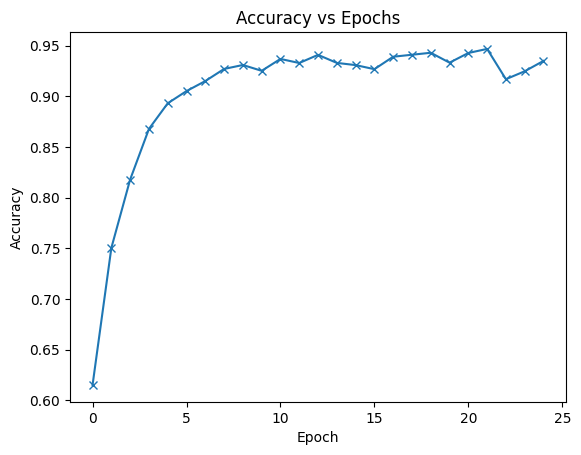

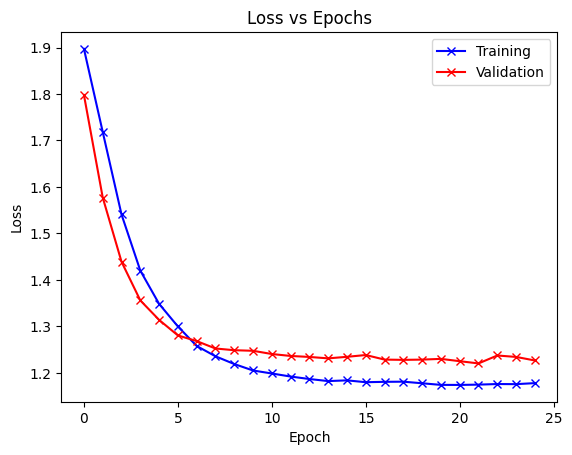

cardboard, accuracy: 98.42%, precision: 96.88%, recall: 91.18%, F1 score: 93.94%
glass, accuracy: 98.22%, precision: 97.52%, recall: 95.16%, F1 score: 96.33%
metal, accuracy: 97.03%, precision: 88.89%, recall: 92.31%, F1 score: 90.57%
paper, accuracy: 97.43%, precision: 94.83%, recall: 94.02%, F1 score: 94.42%
plastic, accuracy: 97.03%, precision: 91.18%, recall: 93.94%, F1 score: 92.54%
trash, accuracy: 98.42%, precision: 76.19%, recall: 84.21%, F1 score: 80.00%


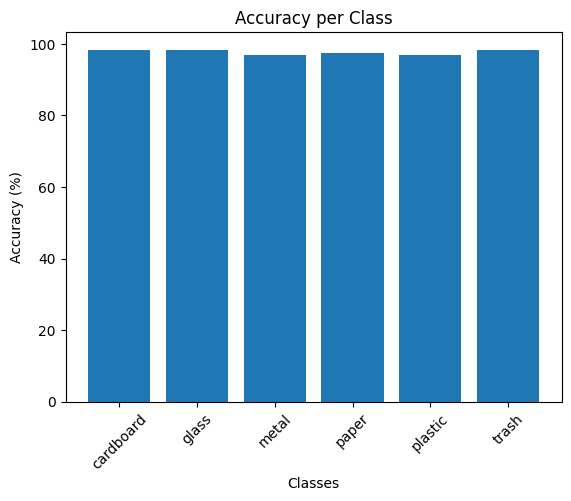

<Figure size 1000x1000 with 0 Axes>

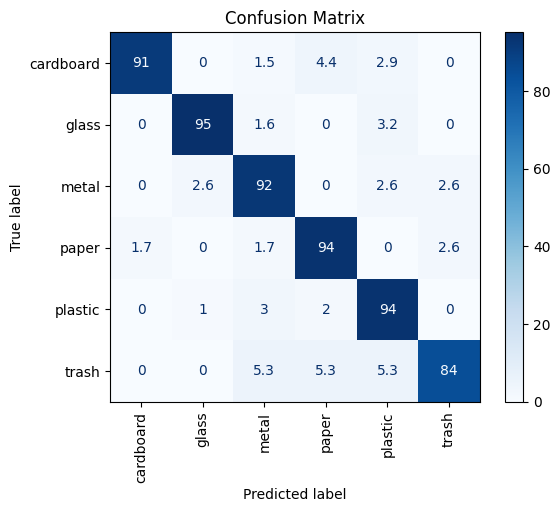

In [11]:
def plot_accuracy(model_history):
    accuracies = [x['Validation Accuracy'] for x in model_history]
    plt.plot(accuracies, '-x')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epochs')
    plt.show()


def plot_loss(model_history):
    train_loss = [x.get('Train Loss') for x in model_history]
    validation_loss = [x['Validation Loss'] for x in model_history]
    plt.plot(train_loss, '-bx')
    plt.plot(validation_loss, '-rx')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs Epochs')
    plt.show()

# Filter out '.DS_Store' from garbage_classes as it's not a real class in the dataset.
# This resolves the ValueError in plot_confusion_matrix due to label mismatch
# and cleans up metrics for other functions.
filtered_garbage_classes = [c for c in garbage_classes if c != '.DS_Store']

def export_classification_metrics(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images, labels = batch
            images = move_to_gpu(images, device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Note: The mapping of `i` to class name assumes `classes` is ordered
    # consistently with how `ImageFolder` assigns numerical labels. If not,
    # per-class metrics may be mislabeled. This fix primarily addresses the `.DS_Store` issue.
    for i, class_name in enumerate(classes):
        class_labels = [1 if label == i else 0 for label in all_labels]
        class_preds = [1 if pred == i else 0 for pred in all_preds]

        accuracy = accuracy_score(class_labels, class_preds) * 100
        precision = precision_score(class_labels, class_preds, zero_division=0) * 100
        recall = recall_score(class_labels, class_preds, zero_division=0) * 100
        f1 = f1_score(class_labels, class_preds, zero_division=0) * 100

        print(
            f'{class_name}, accuracy: {accuracy:.2f}%, precision: {precision:.2f}%, '
            f'recall: {recall:.2f}%, F1 score: {f1:.2f}%'
        )


def plot_accuracy_per_class(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images, labels = batch
            images = move_to_gpu(images, device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracies = []
    # Note: Similar to export_classification_metrics, label ordering matters here.
    for i, class_name in enumerate(classes):
        class_labels = [1 if label == i else 0 for label in all_labels]
        class_preds = [1 if pred == i else 0 for pred in all_preds]

        accuracy = accuracy_score(class_labels, class_preds) * 100
        accuracies.append(accuracy)

    plt.bar(classes, accuracies)
    plt.xlabel('Classes')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy per Class')
    plt.xticks(rotation=45)
    plt.show()


def plot_confusion_matrix(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images, labels = batch
            images = move_to_gpu(images, device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    # Use the filtered classes for display labels to match the confusion matrix dimensions.
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=classes)

    plt.figure(figsize=(10, 10))
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
    plt.title('Confusion Matrix')
    plt.show()


plot_accuracy(model_history)
plot_loss(model_history)
export_classification_metrics(model, validation, filtered_garbage_classes)
plot_accuracy_per_class(model, validation, filtered_garbage_classes)
plot_confusion_matrix(model, validation, filtered_garbage_classes)

## 10. Sample Predictions


Testing No.1 - Class: paper , Predicted Class: paper


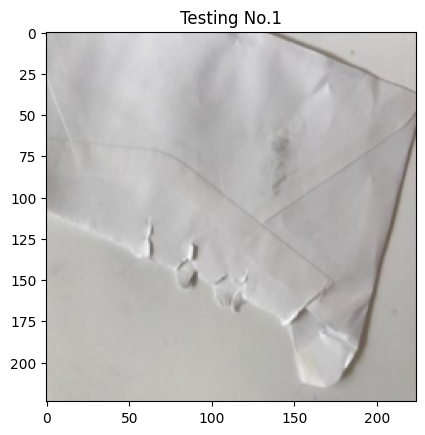

Testing No.2 - Class: cardboard , Predicted Class: cardboard


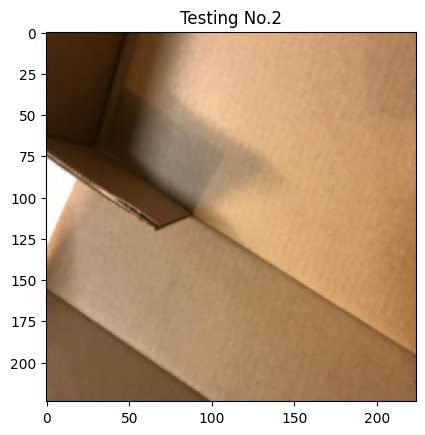

Testing No.3 - Class: paper , Predicted Class: paper


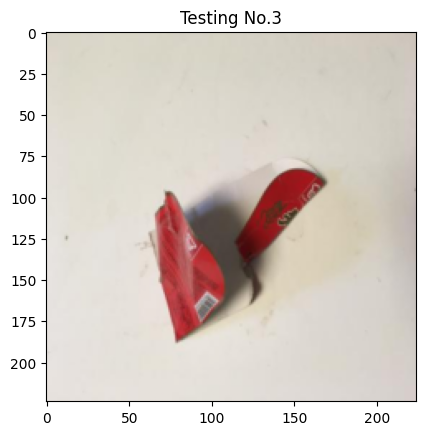

In [13]:
for idx in range(1, 4):
    img, label = random.choice(dataset)
    plt.imshow(denormalize_image(img).permute(1, 2, 0))
    print(f'Testing No.{idx} - Class:', dataset.classes[label], ', Predicted Class:', predict(img, model))
    plt.title(f'Testing No.{idx}')
    plt.show()


## 11. Save Model


In [17]:
# 1. Xác định đường dẫn lưu file
FILE = resolve_output_path('ResnetModel.pth')

# 2. Lấy mô hình gốc (bóc tách khỏi DataParallel nếu có)
model_to_save = model.module if hasattr(model, 'module') else model

# 3. Lưu weights (state_dict) - Đây là cách an toàn và phổ biến nhất
torch.save(model_to_save.state_dict(), FILE)

print(f'✅ Đã lưu mô hình thành công tại: {FILE}')

✅ Đã lưu mô hình thành công tại: /kaggle/working/ResnetModel.pth
